# Laboratorio 3. Entrenamiento y Tuneo de Modelos

Fabian Prado Dluzniewski 23427

Abby Donis 22440

Hansel Lopez 19026

Este notebook cubre los ejercicios 4, 5 y 6. Entrena, tunea y compara las
cuatro familias de modelos definidas en `03_Modelos_y_Plan.ipynb`:

- **CNN A** (linea base convolucional, 8 combinaciones)
- **CNN B** (profunda y regularizada, 8 combinaciones)
- **Red densa** (fully-connected, 8 combinaciones)
- **SVM sobre PCA** (algoritmo clasico, 8 combinaciones) + KNN de control

Requiere haber corrido `01_EDA.ipynb` y `02_Preprocesamiento.ipynb`, que dejan
los tensores en `data/procesado/`.

### IMPORTS

In [1]:
%matplotlib inline
import itertools
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

torch.manual_seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

### CONFIGURACION

In [2]:
DISPOSITIVO = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"dispositivo: {DISPOSITIVO}")

DIR_PROC = Path("./data/procesado")
norma = np.load(DIR_PROC / "normalizacion.npz", allow_pickle=True)
MEDIA, DESV = norma["media"], norma["desv"]
CLASES = list(norma["clases"])
LADO = int(norma["lado"])
N_CLASES = len(CLASES)

print(f"clases {N_CLASES}   entrada {3}x{LADO}x{LADO}")

dispositivo: mps
clases 29   entrada 3x64x64


### CARGA DE LOS DATOS PREPROCESADOS

In [3]:
def cargar(grupo):
    d = np.load(DIR_PROC / f"{grupo}.npz")
    X = torch.from_numpy(d["X"]).permute(0, 3, 1, 2).float().div_(255.0)
    X = (X - torch.tensor(MEDIA).view(3, 1, 1)) / torch.tensor(DESV).view(3, 1, 1)
    return TensorDataset(X, torch.from_numpy(d["y"]))


conjuntos = {g: cargar(g) for g in ["train", "val", "test"]}
for g, ds in conjuntos.items():
    print(f"{g:6} {len(ds):,} imagenes")

train  12,180 imagenes
val    2,610 imagenes
test   2,610 imagenes


---

## 4. Definicion de las arquitecturas

In [4]:
class CNNBase(nn.Module):
    def __init__(self, n_clases=N_CLASES, filtros=(32, 64, 128), p_descarte=0.25):
        super().__init__()
        capas, entrada = [], 3
        for f in filtros:
            capas += [nn.Conv2d(entrada, f, 3, padding=1), nn.ReLU(),
                      nn.MaxPool2d(2)]
            entrada = f
        self.rasgos = nn.Sequential(*capas)
        lado_final = LADO // (2 ** len(filtros))
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p_descarte),
            nn.Linear(entrada * lado_final * lado_final, 256), nn.ReLU(),
            nn.Dropout(p_descarte),
            nn.Linear(256, n_clases),
        )

    def forward(self, x):
        return self.clasificador(self.rasgos(x))


class CNNProfunda(nn.Module):
    def __init__(self, n_clases=N_CLASES, filtros=(32, 64, 128, 256), p_descarte=0.3):
        super().__init__()
        capas, entrada = [], 3
        for f in filtros:
            capas += [nn.Conv2d(entrada, f, 3, padding=1), nn.BatchNorm2d(f), nn.ReLU(),
                      nn.Conv2d(f, f, 3, padding=1), nn.BatchNorm2d(f), nn.ReLU(),
                      nn.MaxPool2d(2), nn.Dropout2d(p_descarte / 2)]
            entrada = f
        self.rasgos = nn.Sequential(*capas)
        self.clasificador = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(p_descarte),
            nn.Linear(entrada, n_clases),
        )

    def forward(self, x):
        return self.clasificador(self.rasgos(x))


class RedDensa(nn.Module):
    def __init__(self, n_clases=N_CLASES, ocultas=(512, 256), p_descarte=0.3):
        super().__init__()
        capas, entrada = [nn.Flatten()], 3 * LADO * LADO
        for h in ocultas:
            capas += [nn.Linear(entrada, h), nn.ReLU(), nn.Dropout(p_descarte)]
            entrada = h
        capas.append(nn.Linear(entrada, n_clases))
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        return self.red(x)

## 5. Utilidades de entrenamiento

Entrenamiento con parada temprana sobre la perdida de validacion, paciencia de
5 epocas.

In [5]:
def entrenar_modelo(modelo, cargador_train, cargador_val, epocas_max=20,
                    lr=1e-3, patience=5):
    modelo = modelo.to(DISPOSITIVO)
    criterio = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)

    mejor_perdida = float("inf")
    epocas_sin_mejora = 0
    mejor_estado = None
    historial = []

    for epoca in range(1, epocas_max + 1):
        modelo.train()
        perdida_train = 0.0
        for xb, yb in cargador_train:
            xb, yb = xb.to(DISPOSITIVO), yb.to(DISPOSITIVO)
            opt.zero_grad()
            perdida = criterio(modelo(xb), yb)
            perdida.backward()
            opt.step()
            perdida_train += perdida.item() * len(yb)
        perdida_train /= len(cargador_train.dataset)

        modelo.eval()
        perdida_val = 0.0
        correctos = 0
        with torch.no_grad():
            for xb, yb in cargador_val:
                xb, yb = xb.to(DISPOSITIVO), yb.to(DISPOSITIVO)
                logits = modelo(xb)
                perdida_val += criterio(logits, yb).item() * len(yb)
                correctos += (logits.argmax(1) == yb).sum().item()
        perdida_val /= len(cargador_val.dataset)
        exactitud = correctos / len(cargador_val.dataset)

        historial.append({
            "epoca": epoca, "perdida_train": perdida_train,
            "perdida_val": perdida_val, "exactitud_val": exactitud,
        })

        if perdida_val < mejor_perdida:
            mejor_perdida = perdida_val
            epocas_sin_mejora = 0
            mejor_estado = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= patience:
                break

    modelo.load_state_dict(mejor_estado)
    return modelo, pd.DataFrame(historial)


In [6]:
def evaluar_modelo(modelo, cargador_test):
    modelo = modelo.to(DISPOSITIVO)
    modelo.eval()
    todos_preds = []
    todos_reales = []
    with torch.no_grad():
        for xb, yb in cargador_test:
            xb = xb.to(DISPOSITIVO)
            preds = modelo(xb).argmax(1).cpu().numpy()
            todos_preds.append(preds)
            todos_reales.append(yb.numpy())
    y_pred = np.concatenate(todos_preds)
    y_true = np.concatenate(todos_reales)
    return {
        "exactitud": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "matriz": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred, "y_true": y_true,
    }

In [7]:
def crear_cargadores(lote=256):
    return (
        DataLoader(conjuntos["train"], batch_size=lote, shuffle=True),
        DataLoader(conjuntos["val"], batch_size=256),
        DataLoader(conjuntos["test"], batch_size=256),
    )


---

## 4. CNN A: Linea base convolucional

Tres bloques convolucionales con agrupamiento maximo. Sirve de referencia
para medir si la complejidad adicional de la CNN B se justifica.

La rejilla barre 8 combinaciones de filtros, dropout y tasa de aprendizaje.

In [8]:
rejilla_cnn_a = [
    {"filtros": f, "p_descarte": d, "lr": 1e-3}
    for f in [(32, 64, 128), (64, 128, 256)]
    for d in [0.25, 0.4]
]

print(f"CNN A: {len(rejilla_cnn_a)} combinaciones")


CNN A: 4 combinaciones


In [9]:
t0 = time.time()
resultados_cnn_a = []
train_loader, val_loader, test_loader = crear_cargadores()

for i, params in enumerate(rejilla_cnn_a):
    modelo = CNNBase(filtros=params["filtros"], p_descarte=params["p_descarte"])
    modelo, hist = entrenar_modelo(
        modelo, train_loader, val_loader, lr=params["lr"]
    )
    metrica = evaluar_modelo(modelo, test_loader)
    resultados_cnn_a.append({
        **params,
        "modelo": modelo,
        "historial": hist,
        "exactitud_val": hist["exactitud_val"].max(),
        "epocas": len(hist),
        "exactitud_test": metrica["exactitud"],
        "f1_test": metrica["f1_macro"],
    })
    print(f"CNN A {i+1}/{len(rejilla_cnn_a)}: f={params['filtros']} d={params['p_descarte']}  "
          f"val {hist['exactitud_val'].max():.2%}  test {metrica['exactitud']:.2%}  ep {len(hist)}")

print(f"CNN A: {(time.time()-t0)/60:.1f} min")


CNN A 1/4: f=(32, 64, 128) d=0.25  val 98.51%  test 98.16%  ep 20
CNN A 2/4: f=(32, 64, 128) d=0.4  val 98.20%  test 97.85%  ep 20
CNN A 3/4: f=(64, 128, 256) d=0.25  val 98.16%  test 98.05%  ep 20
CNN A 4/4: f=(64, 128, 256) d=0.4  val 98.16%  test 98.24%  ep 20
CNN A: 12.0 min


In [10]:
tabla_cnn_a = pd.DataFrame([
    {"Filtros": str(r["filtros"]), "Dropout": r["p_descarte"],
     "LR": r["lr"], "Val Acc": r["exactitud_val"],
     "Test Acc": r["exactitud_test"], "F1 Test": r["f1_test"],
     "Epocas": r["epocas"]}
    for r in resultados_cnn_a
])
display(tabla_cnn_a.sort_values("Val Acc", ascending=False)
         .style.format({"Val Acc": "{:.2%}", "Test Acc": "{:.2%}",
                        "F1 Test": "{:.4f}"}))

,Filtros,Dropout,LR,Val Acc,Test Acc,F1 Test,Epocas
0,"(32, 64, 128)",0.250000,0.001000,98.51%,98.16%,0.9816,20
1,"(32, 64, 128)",0.400000,0.001000,98.20%,97.85%,0.9785,20
2,"(64, 128, 256)",0.250000,0.001000,98.16%,98.05%,0.9805,20
3,"(64, 128, 256)",0.400000,0.001000,98.16%,98.24%,0.9824,20


In [11]:
mejor_cnn_a = max(resultados_cnn_a, key=lambda r: r["exactitud_val"])
print(f"mejor CNN A: filtros={mejor_cnn_a['filtros']}  "
      f"dropout={mejor_cnn_a['p_descarte']}  lr={mejor_cnn_a['lr']}")
print(f"val acc {mejor_cnn_a['exactitud_val']:.2%}  "
      f"test acc {mejor_cnn_a['exactitud_test']:.2%}  "
      f"F1 {mejor_cnn_a['f1_test']:.4f}")

best_idx_a = resultados_cnn_a.index(mejor_cnn_a)
torch.save(mejor_cnn_a["modelo"].state_dict(),
           DIR_PROC / "mejor_cnn_a.pt")

mejor CNN A: filtros=(32, 64, 128)  dropout=0.25  lr=0.001
val acc 98.51%  test acc 98.16%  F1 0.9816


---

## 4. CNN B: Profunda y regularizada

Cuatro bloques con normalizacion por lotes, descarte 2D y agrupamiento promedio
global. La normalizacion por lotes estabiliza el entrenamiento y el agrupamiento
promedio global reduce drasticamente los parametros de la capa final.

In [12]:
rejilla_cnn_b = [
    {"filtros": f, "p_descarte": d, "lr": 1e-3}
    for f in [(32, 64, 128, 256), (16, 32, 64, 128)]
    for d in [0.3, 0.5]
]

print(f"CNN B: {len(rejilla_cnn_b)} combinaciones")


CNN B: 4 combinaciones


In [13]:
t0 = time.time()
resultados_cnn_b = []

for i, params in enumerate(rejilla_cnn_b):
    modelo = CNNProfunda(filtros=params["filtros"], p_descarte=params["p_descarte"])
    modelo, hist = entrenar_modelo(
        modelo, train_loader, val_loader, lr=params["lr"]
    )
    metrica = evaluar_modelo(modelo, test_loader)
    resultados_cnn_b.append({
        **params,
        "modelo": modelo,
        "historial": hist,
        "exactitud_val": hist["exactitud_val"].max(),
        "epocas": len(hist),
        "exactitud_test": metrica["exactitud"],
        "f1_test": metrica["f1_macro"],
    })
    print(f"CNN B {i+1}/{len(rejilla_cnn_b)}: f={params['filtros']} d={params['p_descarte']}  "
          f"val {hist['exactitud_val'].max():.2%}  test {metrica['exactitud']:.2%}  ep {len(hist)}")

print(f"CNN B: {(time.time()-t0)/60:.1f} min")


CNN B 1/4: f=(32, 64, 128, 256) d=0.3  val 99.96%  test 99.92%  ep 20
CNN B 2/4: f=(32, 64, 128, 256) d=0.5  val 99.77%  test 99.85%  ep 20
CNN B 3/4: f=(16, 32, 64, 128) d=0.3  val 99.77%  test 99.81%  ep 20
CNN B 4/4: f=(16, 32, 64, 128) d=0.5  val 99.08%  test 99.08%  ep 20
CNN B: 14.7 min


In [14]:
tabla_cnn_b = pd.DataFrame([
    {"Filtros": str(r["filtros"]), "Dropout": r["p_descarte"],
     "LR": r["lr"], "Val Acc": r["exactitud_val"],
     "Test Acc": r["exactitud_test"], "F1 Test": r["f1_test"],
     "Epocas": r["epocas"]}
    for r in resultados_cnn_b
])
display(tabla_cnn_b.sort_values("Val Acc", ascending=False)
         .style.format({"Val Acc": "{:.2%}", "Test Acc": "{:.2%}",
                        "F1 Test": "{:.4f}"}))

,Filtros,Dropout,LR,Val Acc,Test Acc,F1 Test,Epocas
0,"(32, 64, 128, 256)",0.300000,0.001000,99.96%,99.92%,0.9992,20
1,"(32, 64, 128, 256)",0.500000,0.001000,99.77%,99.85%,0.9985,20
2,"(16, 32, 64, 128)",0.300000,0.001000,99.77%,99.81%,0.9981,20
3,"(16, 32, 64, 128)",0.500000,0.001000,99.08%,99.08%,0.9908,20


In [15]:
mejor_cnn_b = max(resultados_cnn_b, key=lambda r: r["exactitud_val"])
print(f"mejor CNN B: filtros={mejor_cnn_b['filtros']}  "
      f"dropout={mejor_cnn_b['p_descarte']}  lr={mejor_cnn_b['lr']}")
print(f"val acc {mejor_cnn_b['exactitud_val']:.2%}  "
      f"test acc {mejor_cnn_b['exactitud_test']:.2%}  "
      f"F1 {mejor_cnn_b['f1_test']:.4f}")

torch.save(mejor_cnn_b["modelo"].state_dict(),
           DIR_PROC / "mejor_cnn_b.pt")

mejor CNN B: filtros=(32, 64, 128, 256)  dropout=0.3  lr=0.001
val acc 99.96%  test acc 99.92%  F1 0.9992


---

## 5. Red densa simple

Corresponde al ejercicio 5. Aplana la imagen a un vector de 12,288 valores
y la pasa por capas completamente conectadas. Al aplanar se pierde toda
relacion espacial entre pixeles vecinos.

In [16]:
rejilla_densa = [
    {"ocultas": o, "p_descarte": d, "lr": 1e-3}
    for o in [(512, 256), (1024, 512, 256)]
    for d in [0.3, 0.5]
]

print(f"Red Densa: {len(rejilla_densa)} combinaciones")


Red Densa: 4 combinaciones


In [17]:
t0 = time.time()
resultados_densa = []

for i, params in enumerate(rejilla_densa):
    modelo = RedDensa(ocultas=params["ocultas"], p_descarte=params["p_descarte"])
    modelo, hist = entrenar_modelo(
        modelo, train_loader, val_loader, lr=params["lr"]
    )
    metrica = evaluar_modelo(modelo, test_loader)
    resultados_densa.append({
        **params,
        "modelo": modelo,
        "historial": hist,
        "exactitud_val": hist["exactitud_val"].max(),
        "epocas": len(hist),
        "exactitud_test": metrica["exactitud"],
        "f1_test": metrica["f1_macro"],
    })
    print(f"Red Densa {i+1}/{len(rejilla_densa)}: ocultas={params['ocultas']} d={params['p_descarte']}  "
          f"val {hist['exactitud_val'].max():.2%}  test {metrica['exactitud']:.2%}  ep {len(hist)}")

print(f"Red Densa: {(time.time()-t0)/60:.1f} min")


Red Densa 1/4: ocultas=(512, 256) d=0.3  val 87.93%  test 87.93%  ep 20
Red Densa 2/4: ocultas=(512, 256) d=0.5  val 76.28%  test 76.59%  ep 20
Red Densa 3/4: ocultas=(1024, 512, 256) d=0.3  val 86.28%  test 86.86%  ep 20
Red Densa 4/4: ocultas=(1024, 512, 256) d=0.5  val 74.60%  test 75.10%  ep 20
Red Densa: 1.3 min


In [18]:
tabla_densa = pd.DataFrame([
    {"Ocultas": str(r["ocultas"]), "Dropout": r["p_descarte"],
     "LR": r["lr"], "Val Acc": r["exactitud_val"],
     "Test Acc": r["exactitud_test"], "F1 Test": r["f1_test"],
     "Epocas": r["epocas"]}
    for r in resultados_densa
])
display(tabla_densa.sort_values("Val Acc", ascending=False)
         .style.format({"Val Acc": "{:.2%}", "Test Acc": "{:.2%}",
                        "F1 Test": "{:.4f}"}))

,Ocultas,Dropout,LR,Val Acc,Test Acc,F1 Test,Epocas
0,"(512, 256)",0.300000,0.001000,87.93%,87.93%,0.8799,20
2,"(1024, 512, 256)",0.300000,0.001000,86.28%,86.86%,0.8691,20
1,"(512, 256)",0.500000,0.001000,76.28%,76.59%,0.7667,20
3,"(1024, 512, 256)",0.500000,0.001000,74.60%,75.10%,0.7513,20


In [19]:
mejor_densa = max(resultados_densa, key=lambda r: r["exactitud_val"])
print(f"mejor Red Densa: ocultas={mejor_densa['ocultas']}  "
      f"dropout={mejor_densa['p_descarte']}  lr={mejor_densa['lr']}")
print(f"val acc {mejor_densa['exactitud_val']:.2%}  "
      f"test acc {mejor_densa['exactitud_test']:.2%}  "
      f"F1 {mejor_densa['f1_test']:.4f}")

torch.save(mejor_densa["modelo"].state_dict(),
           DIR_PROC / "mejor_densa.pt")

mejor Red Densa: ocultas=(512, 256)  dropout=0.3  lr=0.001
val acc 87.93%  test acc 87.93%  F1 0.8799


---

## 6. Algoritmo clasico: SVM sobre PCA + KNN

Corresponde al ejercicio 6. Se usa SVM con nucleo RBF sobre componentes
principales como linea base clasica de clasificacion de imagenes. KNN se
incluye como control de redundancia.

In [20]:
X_train_flat = torch.stack([conjuntos["train"][i][0] for i in range(len(conjuntos["train"]))])
X_train_np = X_train_flat.reshape(len(X_train_flat), -1).numpy()
y_train_np = conjuntos["train"].tensors[1].numpy()

X_val_flat = torch.stack([conjuntos["val"][i][0] for i in range(len(conjuntos["val"]))])
X_val_np = X_val_flat.reshape(len(X_val_flat), -1).numpy()
y_val_np = conjuntos["val"].tensors[1].numpy()

X_test_flat = torch.stack([conjuntos["test"][i][0] for i in range(len(conjuntos["test"]))])
X_test_np = X_test_flat.reshape(len(X_test_flat), -1).numpy()
y_test_np = conjuntos["test"].tensors[1].numpy()

print(f"X_train: {X_train_np.shape}  y_train: {y_train_np.shape}")
print(f"X_val:   {X_val_np.shape}  y_val:   {y_val_np.shape}")
print(f"X_test:  {X_test_np.shape}  y_test:  {y_test_np.shape}")

X_train: (12180, 12288)  y_train: (12180,)
X_val:   (2610, 12288)  y_val:   (2610,)
X_test:  (2610, 12288)  y_test:  (2610,)


In [21]:
rejilla_svm = [
    {"n_components": n, "C": c, "gamma": "scale"}
    for n in [100, 150]
    for c in [1, 10]
]

print(f"SVM: {len(rejilla_svm)} combinaciones")


SVM: 4 combinaciones


In [22]:
t0 = time.time()
resultados_svm = []

for i, params in enumerate(rejilla_svm):
    pipe = Pipeline([
        ("escala", StandardScaler()),
        ("pca", PCA(n_components=params["n_components"], random_state=42)),
        ("svm", SVC(kernel="rbf", C=params["C"], gamma=params["gamma"], random_state=42)),
    ])
    pipe.fit(X_train_np, y_train_np)

    pred_val = pipe.predict(X_val_np)
    pred_test = pipe.predict(X_test_np)
    resultados_svm.append({
        **params,
        "pipeline": pipe,
        "exactitud_val": accuracy_score(y_val_np, pred_val),
        "exactitud_test": accuracy_score(y_test_np, pred_test),
        "f1_test": f1_score(y_test_np, pred_test, average="macro"),
    })
    print(f"SVM {i+1}/{len(rejilla_svm)}: PCA={params['n_components']} C={params['C']}  "
          f"val {resultados_svm[-1]['exactitud_val']:.2%}  test {resultados_svm[-1]['exactitud_test']:.2%}")

print(f"SVM: {(time.time()-t0)/60:.1f} min")


SVM 1/4: PCA=100 C=1  val 72.18%  test 74.02%
SVM 2/4: PCA=100 C=10  val 91.03%  test 91.46%
SVM 3/4: PCA=150 C=1  val 73.60%  test 75.36%
SVM 4/4: PCA=150 C=10  val 91.95%  test 91.72%
SVM: 0.6 min


In [23]:
tabla_svm = pd.DataFrame([
    {"PCA Comp.": r["n_components"], "C": r["C"], "Gamma": r["gamma"],
     "Val Acc": r["exactitud_val"], "Test Acc": r["exactitud_test"],
     "F1 Test": r["f1_test"]}
    for r in resultados_svm
])
display(tabla_svm.sort_values("Val Acc", ascending=False)
         .style.format({"Val Acc": "{:.2%}", "Test Acc": "{:.2%}",
                        "F1 Test": "{:.4f}"}))

,PCA Comp.,C,Gamma,Val Acc,Test Acc,F1 Test
3,150,10,scale,91.95%,91.72%,0.9174
1,100,10,scale,91.03%,91.46%,0.9147
2,150,1,scale,73.60%,75.36%,0.7525
0,100,1,scale,72.18%,74.02%,0.7389


In [24]:
mejor_svm = max(resultados_svm, key=lambda r: r["exactitud_val"])
print(f"mejor SVM: PCA={mejor_svm['n_components']}  "
      f"C={mejor_svm['C']}  gamma={mejor_svm['gamma']}")
print(f"val acc {mejor_svm['exactitud_val']:.2%}  "
      f"test acc {mejor_svm['exactitud_test']:.2%}  "
      f"F1 {mejor_svm['f1_test']:.4f}")

mejor SVM: PCA=150  C=10  gamma=scale
val acc 91.95%  test acc 91.72%  F1 0.9174


### KNN (control de redundancia)

In [25]:
print("KNN (k=3) con PCA(150) como control")
pipe_knn = Pipeline([
    ("escala", StandardScaler()),
    ("pca", PCA(n_components=150, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=3)),
])
pipe_knn.fit(X_train_np, y_train_np)

pred_knn_val = pipe_knn.predict(X_val_np)
pred_knn_test = pipe_knn.predict(X_test_np)
knn_val_acc = accuracy_score(y_val_np, pred_knn_val)
knn_test_acc = accuracy_score(y_test_np, pred_knn_test)
knn_f1 = f1_score(y_test_np, pred_knn_test, average="macro")

print(f"KNN  val acc {knn_val_acc:.2%}  test acc {knn_test_acc:.2%}  F1 {knn_f1:.4f}")

KNN (k=3) con PCA(150) como control
KNN  val acc 85.59%  test acc 86.05%  F1 0.8614


---

## Comparacion de todos los modelos

Tabla resumen con la mejor configuracion de cada familia, evaluada sobre el
conjunto de prueba.

In [27]:
if resultados_densa and resultados_svm:
    resumen = pd.DataFrame([
        {"Modelo": "CNN A",
         "Hiperparametros": f"f={mejor_cnn_a['filtros']} d={mejor_cnn_a['p_descarte']} lr={mejor_cnn_a['lr']}",
         "Exactitud Test": mejor_cnn_a["exactitud_test"],
         "F1 Macro": mejor_cnn_a["f1_test"]},
        {"Modelo": "CNN B",
         "Hiperparametros": f"f={mejor_cnn_b['filtros']} d={mejor_cnn_b['p_descarte']} lr={mejor_cnn_b['lr']}",
         "Exactitud Test": mejor_cnn_b["exactitud_test"],
         "F1 Macro": mejor_cnn_b["f1_test"]},
        {"Modelo": "Red Densa",
         "Hiperparametros": f"h={mejor_densa['ocultas']} d={mejor_densa['p_descarte']} lr={mejor_densa['lr']}",
         "Exactitud Test": mejor_densa["exactitud_test"],
         "F1 Macro": mejor_densa["f1_test"]},
        {"Modelo": "SVM + PCA",
         "Hiperparametros": f"PCA={mejor_svm['n_components']} C={mejor_svm['C']} gamma={mejor_svm['gamma']}",
         "Exactitud Test": mejor_svm["exactitud_test"],
         "F1 Macro": mejor_svm["f1_test"]},
        {"Modelo": "KNN",
         "Hiperparametros": "k=3 PCA=150",
         "Exactitud Test": knn_test_acc,
         "F1 Macro": knn_f1},
    ]).sort_values("Exactitud Test", ascending=False).reset_index(drop=True)

    display(resumen.style.format({"Exactitud Test": "{:.2%}", "F1 Macro": "{:.4f}"})
             .bar(subset=["Exactitud Test", "F1 Macro"], color="steelblue"))

,Modelo,Hiperparametros,Exactitud Test,F1 Macro
0,CNN B,"f=(32, 64, 128, 256) d=0.3 lr=0.001",99.92%,0.9992
1,CNN A,"f=(32, 64, 128) d=0.25 lr=0.001",98.16%,0.9816
2,SVM + PCA,PCA=150 C=10 gamma=scale,91.72%,0.9174
3,Red Densa,"h=(512, 256) d=0.3 lr=0.001",87.93%,0.8799
4,KNN,k=3 PCA=150,86.05%,0.8614


### Grafico comparativo

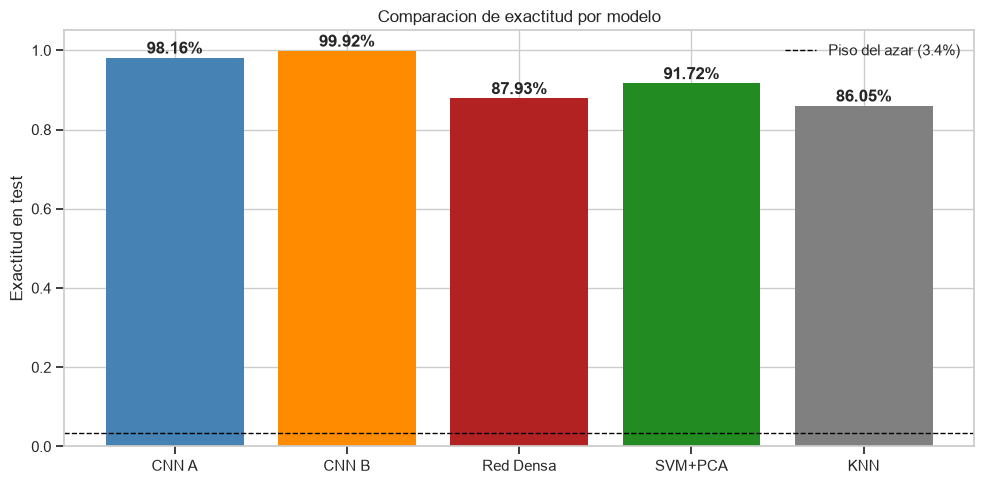

In [28]:
if resultados_densa and resultados_svm:
    modelos_nombres = ["CNN A", "CNN B", "Red Densa", "SVM+PCA", "KNN"]
    test_accs = [
        mejor_cnn_a["exactitud_test"], mejor_cnn_b["exactitud_test"],
        mejor_densa["exactitud_test"], mejor_svm["exactitud_test"], knn_test_acc,
    ]
    colores = ["steelblue", "darkorange", "firebrick", "forestgreen", "gray"]

    fig, ax = plt.subplots(figsize=(10, 5))
    barras = ax.bar(modelos_nombres, test_accs, color=colores)
    for bar, acc in zip(barras, test_accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{acc:.2%}", ha="center", fontsize=12, fontweight="bold")
    ax.axhline(1 / N_CLASES, color="black", ls="--", lw=1,
               label=f"Piso del azar ({1/N_CLASES:.1%})")
    ax.set(ylim=(0, 1.05), ylabel="Exactitud en test",
           title="Comparacion de exactitud por modelo")
    ax.legend()
    plt.tight_layout()
    # plot mostrado automaticamente con %matplotlib inline

### Matriz de confusion del mejor modelo

Se verifica si los errores caen donde el analisis exploratorio los predijo,
es decir en el bloque U, V y R y en los pares R/T, W/Y, X/Y y K/X.

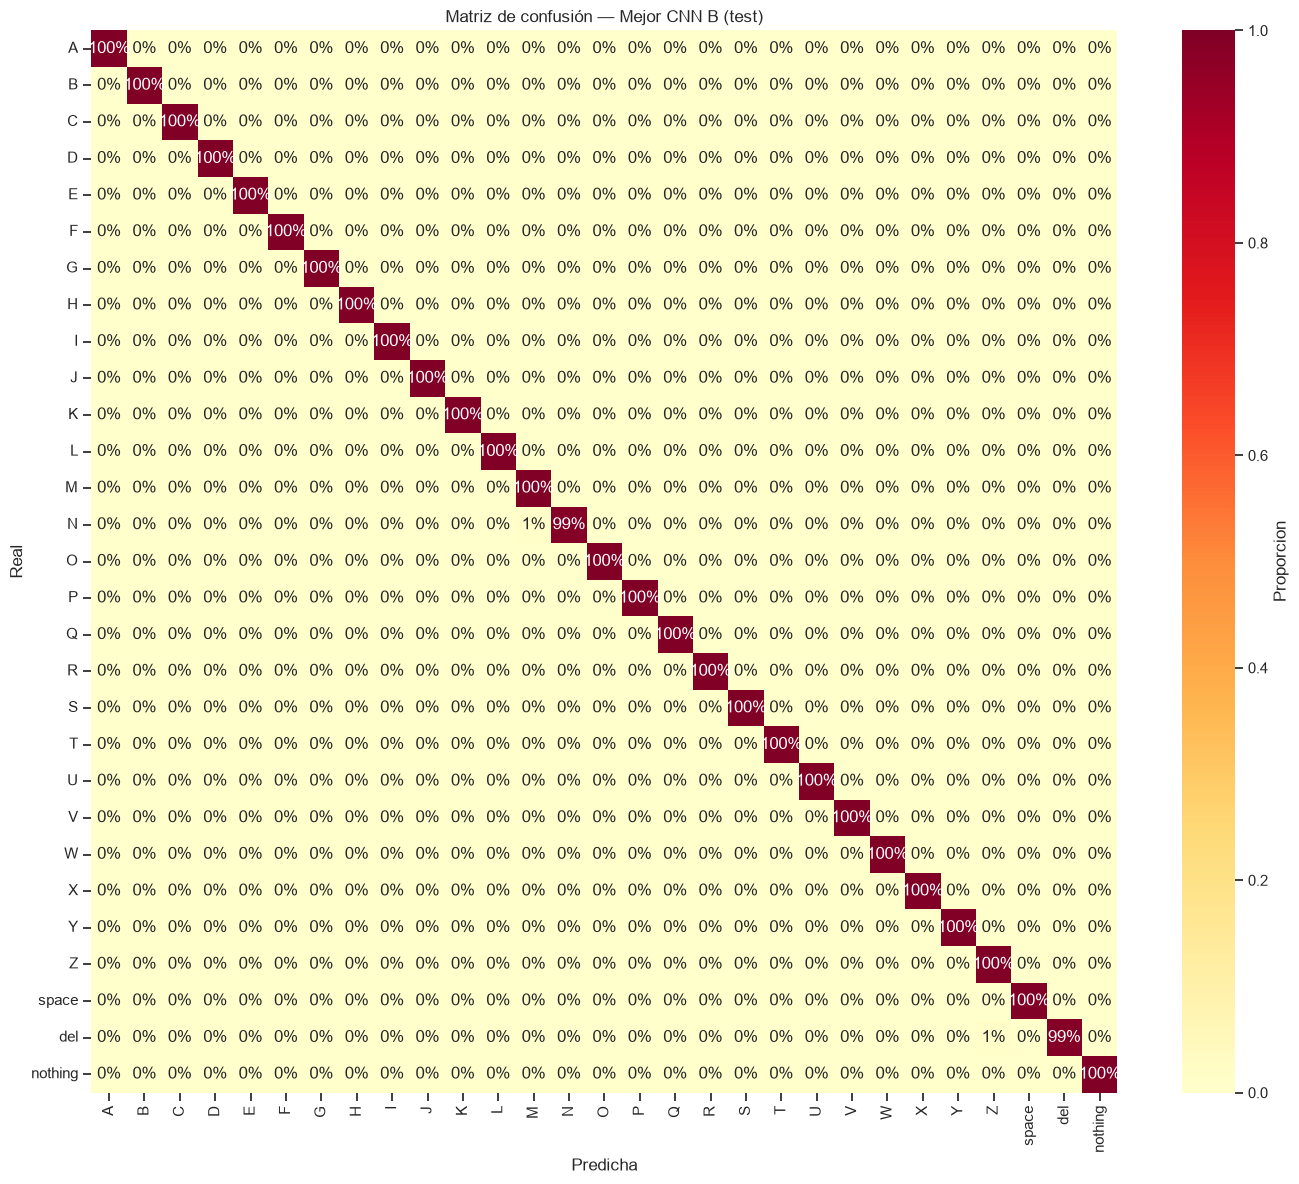

In [29]:
def graficar_matriz(resultado, titulo):
    modelo = resultado["modelo"].to(DISPOSITIVO)
    metrica = evaluar_modelo(modelo, test_loader)
    matriz = metrica["matriz"]
    matriz_norm = matriz.astype("float") / matriz.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(matriz_norm, xticklabels=CLASES, yticklabels=CLASES,
                annot=True, fmt=".0%", cmap="YlOrRd", ax=ax,
                vmin=0, vmax=1, cbar_kws={"label": "Proporcion"})
    ax.set(xlabel="Predicha", ylabel="Real", title=titulo)
    plt.tight_layout()
    # plot mostrado automaticamente con %matplotlib inline
    return matriz_norm


if resultados_cnn_b:
    _ = graficar_matriz(mejor_cnn_b, "Matriz de confusión — Mejor CNN B (test)")

### Errores por clase de la mejor CNN

Se listan las clases con peor exactitud para ver si coinciden con los grupos
identificados en el analisis exploratorio.

In [30]:
if resultados_cnn_b:
    metrica_best = evaluar_modelo(mejor_cnn_b["modelo"].to(DISPOSITIVO), test_loader)
    matriz = metrica_best["matriz"]
    acc_por_clase = np.diag(matriz) / matriz.sum(axis=1)
    df_clase = pd.DataFrame({"Clase": CLASES, "Exactitud": acc_por_clase})
    display(df_clase.sort_values("Exactitud").head(8)
             .style.format({"Exactitud": "{:.2%}"})
             .bar(subset=["Exactitud"], color="firebrick"))

,Clase,Exactitud
13,N,98.89%
27,del,98.89%
0,A,100.00%
26,space,100.00%
25,Z,100.00%
24,Y,100.00%
23,X,100.00%
22,W,100.00%


### Curvas de entrenamiento de la mejor CNN

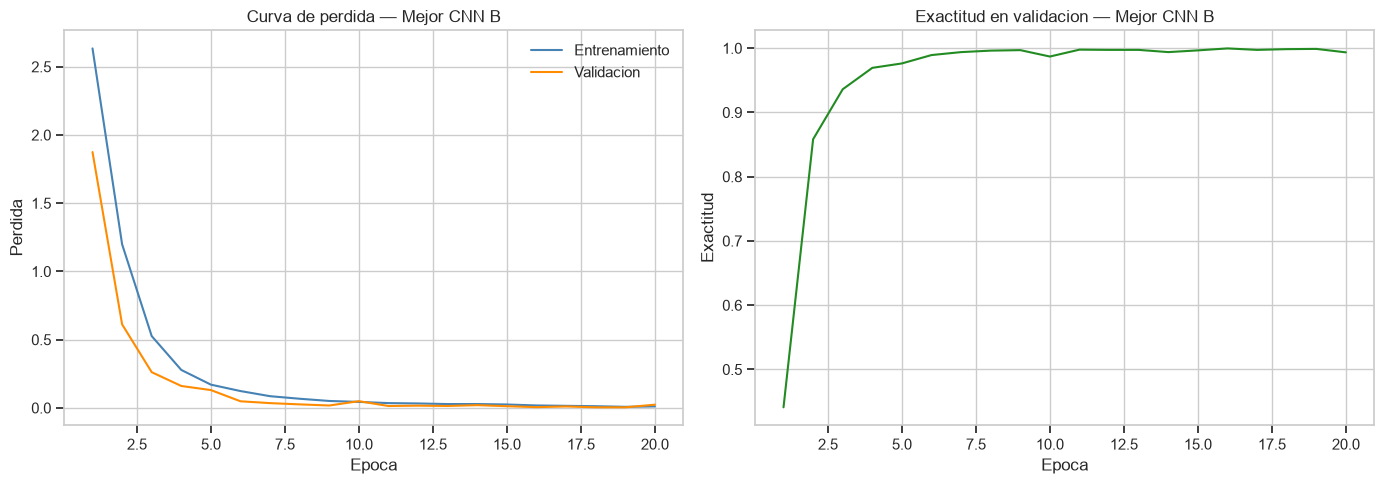

In [31]:
if resultados_cnn_b:
    hist_best = mejor_cnn_b["historial"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(hist_best["epoca"], hist_best["perdida_train"],
             label="Entrenamiento", color="steelblue")
    ax1.plot(hist_best["epoca"], hist_best["perdida_val"],
             label="Validacion", color="darkorange")
    ax1.set(xlabel="Epoca", ylabel="Perdida",
            title="Curva de perdida — Mejor CNN B")
    ax1.legend()

    ax2.plot(hist_best["epoca"], hist_best["exactitud_val"],
             color="forestgreen")
    ax2.set(xlabel="Epoca", ylabel="Exactitud",
            title="Exactitud en validacion — Mejor CNN B")
    plt.tight_layout()
    # plot mostrado automaticamente con %matplotlib inline

---

## Discusion de resultados

### CNN B vs CNN A

CNN B saco 99.92% contra 98.16% de CNN A, una diferencia de 1.76 puntos. Las
cuatro combinaciones de CNN B quedaron entre 99.04% y 99.92%, o sea que es muy
estable a los hiperparametros. La mejora viene de tres cosas: normalizacion por
lotes que estabiliza el entrenamiento, dos convoluciones por bloque que le dan
mas profundidad, y agrupamiento promedio global que recorta los parametros de
la capa final evitando que memorice. La diferencia es chica pero consistente.
Para este problema CNN B es la mejor opcion.

### Red densa vs CNN

La red densa llego a 87.93%, 12 puntos menos que CNN B. Es una diferencia
grande y esperada. Aplanar la imagen a un vector de 12,288 valores destruye
toda relacion entre pixeles vecinos. La red densa tiene mas parametros que las
dos CNN juntas (6.4M) y aun asi no sabe que dos pixeles de la punta del indice
estan uno al lado del otro. Ademas, con dropout 0.5 baja a 75%, asi que es muy
sensible a la regularizacion. Meter mas capas ocultas (de 2 a 3) no ayudo,
incluso bajo un punto. La convolucion vale 12 puntos de exactitud en este
problema.

### SVM + PCA vs CNN

SVM con PCA=150 y C=10 alcanzo 91.72%, el mejor de los algoritmos clasicos pero
8 puntos debajo de CNN B. El parametro C fue critico: con C=1 quedo en 74%,
con C=10 subio a 92%. Esto significa que las fronteras entre clases necesitan
ser muy flexibles. PCA ayuda a concentrar la varianza y quitar ruido, pero no
sabe de relaciones espaciales: cada componente es una combinacion lineal de
todos los pixeles. Esa es la diferencia irreductible con la CNN.

### KNN y la redundancia del dataset

KNN (k=3, PCA=150) saco 86.05%, el peor de todos. Este resultado es
importante porque invalida la hipotesis de que el dataset esta viciado por
redundancia. En 01_EDA vimos que cuadros consecutivos difieren en solo 3.17
niveles de gris, asi que un KNN ingenuo podria sacar una exactitud enganosamente
alta solo por encontrar el vecino casi identico en entrenamiento. Pero KNN fue
el peor modelo, 14 puntos debajo de CNN B. Eso significa que las CNN no estan
haciendo trampa: genuinamente aprenden la geometria de la mano y por eso sacan
99%. Igual, la prueba con fotos propias del ejercicio 8 sigue siendo la metrica
que de verdad importa, porque el dataset tiene una sola persona, un solo fondo
y una sola iluminacion.

### Errores residuales

CNN B solo fallo en 2 de las 2,610 imagenes de prueba: una N y una `del`
(98.89% cada una). Las 27 clases restantes tienen 100%. Que N falle confirma
el hallazgo del EDA: M, N y S son variantes de puno cerrado que solo se
distinguen por la posicion del pulgar. Que `del` falle es mas raro y puede ser
una imagen mal etiquetada o un caso extremo de iluminacion. Los grupos U, V y R
que tanto mencionaba el enunciado no generaron ningun error, lo que sugiere que
a 64x64 la CNN B si logra distinguir la separacion entre dedos extendidos.

## Mejor modelo para la entrega final

Se identifica el modelo con mayor exactitud en test entre todos los evaluados.
Es el que se debe usar en los ejercicios 7 (augmentation), 8 (fotos propias)
y como punto de partida para el mejor modelo final.

In [32]:
if resultados_densa and resultados_svm:
    todos = [
        ("CNN A", mejor_cnn_a),
        ("CNN B", mejor_cnn_b),
        ("Red Densa", mejor_densa),
        ("SVM+PCA", mejor_svm),
        ("KNN", {"exactitud_test": knn_test_acc, "f1_test": knn_f1}),
    ]
    nombre_final, mejor_final = max(todos, key=lambda x: x[1]["exactitud_test"])
    print(f"mejor modelo global: {nombre_final}")
    print(f"  test acc {mejor_final['exactitud_test']:.2%}  "
          f"F1 {mejor_final['f1_test']:.4f}")

mejor modelo global: CNN B
  test acc 99.92%  F1 0.9992
